### HW 2 Statistics - Numpy/Python

1) *Write functions to compute the mean, and standard deviation of a list of data*

In [ ]:

import random 
import math

def mean(data):
    sum = 0
    for num in data:
        sum += num
    return sum / float(len(data))

def std_dev(data):
    d_mean = mean(data)
    square_sum = 0
    for num in data:
        square_sum += (num - d_mean) ** 2
    return math.sqrt(square_sum / len(data))
    

data = []
for i in range(1000):
    data.append(random.randint(0, 1000000))
data_mean = mean(data)
data_stddev = std_dev(data)
print(f"Mean is {data_mean:,.2f}")
print(f"Standard Deviation is {data_stddev:,.2f}")


Mean is 503,305.33
Standard Deviation is 277,974.17


2) *Use scipy.stats.norm to sample from the normal(gaussian) distribution. Compute the mean, and standard deviation of your set of samples using your functions, and with the built in numpy methods. Verify you get the expected results (you know what these values should be if you sample from a normal distribution).*

In [28]:
import scipy as sc
import numpy as np
from scipy.stats import norm

samples = norm.rvs(size=10000, random_state=42)

my_mean = mean(samples)
my_stddev = std_dev(samples)
np_mean = np.mean(samples)
np_stddev = np.std(samples)

print(f"My mean: {my_mean:,.5f}\nMy std: {my_stddev:,.5f}\nNP mean: {np_mean:,.5f}\nNP std: {np_stddev:,.5f}")



My mean: -0.00214
My std: 1.00341
NP mean: -0.00214
NP std: 1.00341


3) *Plot a histogram of your samples*

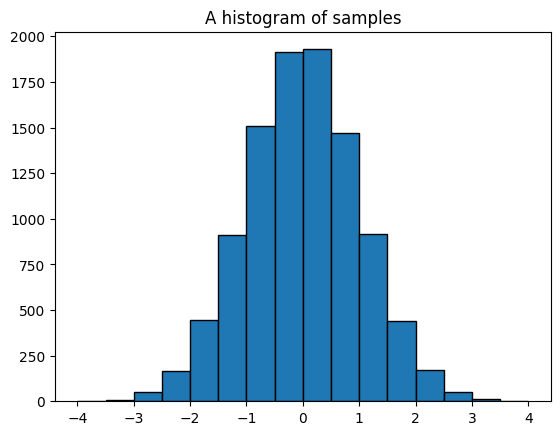

In [33]:
import matplotlib.pyplot as plt

custom_bounds = np.arange(-4, 4.5, 0.5)
plt.hist(samples, bins=custom_bounds, edgecolor='black')
plt.title("A histogram of samples")
plt.show()


### Part 2: A/B Hypothesis Testing

$H_0$: B and A are not different. More explicitly, $p_B - p_A = 0$ 

$H_a$: B is better than A, or $p_B > p_A$

$Z = \frac{p_A - p_B}{\sqrt(\hat{p}\hat{q}(\frac{1}{N_A} + \frac{1}{N_B}))}$

In [40]:
nA = 1000
nB = 1000
pA = 500 / float(nA)
pB = 570 / float(nB)
pHat = pA * (nA / (nA + nB)) + pB * (nB / (nA + nB))
qHat = 1 - pHat

z = (pA - pB) / math.sqrt(pHat * qHat * (1 / nA + 1 / nB))
one_sided_p_value = norm.cdf(z)

print(f"Z-value: {z}\nP-value: {one_sided_p_value}")

Z-value: -3.1381931834476844
P-value: 0.0008499639954567179


With a threshold $\alpha < 0.05$ we would reject the null-hypothesis. We would be unable to reject the null hypothesis with a stricter $\alpha < 0.01$ test. 

That changes if campaign B had click-through values of 560 and 570, which give $p$-values of 0.03% and 0.008% respectively and correspond to orders of magnitude more confidence in rejecting the null hypothesis. 